In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

/Users/daray/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [37]:
data = pd.read_csv("healthcare_dataset.csv")
data.shape

(55500, 15)

Check the null and duplicates on the datasets. Remove duplicates and null rows

In [38]:
#null and duplicatess
#0 null data  
data.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [39]:
#534 duplicated row 
data.loc[data.duplicated()]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
50023,Samuel joYCe,56,Male,O+,Arthritis,2022-11-03,Krista Hartman,Thomas-Ballard,UnitedHealthcare,15654.830587,157,Urgent,2022-11-22,Aspirin,Inconclusive
50040,KIMBErly vasqueZ,26,Male,A-,Obesity,2023-10-23,Jennifer Bennett,Cowan Inc,UnitedHealthcare,38142.109678,313,Urgent,2023-11-18,Penicillin,Abnormal
50055,SCoTT tHOrNton,55,Female,B-,Obesity,2021-04-08,Joshua Ingram,Keller LLC,Medicare,30894.904511,455,Urgent,2021-04-15,Aspirin,Abnormal
50070,wiLliam LEe,27,Female,O+,Arthritis,2020-01-31,Lauren Montgomery,Winters-Simon,Cigna,46229.434901,153,Elective,2020-02-13,Lipitor,Normal
50078,chRistOPheR NoRrIs,38,Male,AB-,Arthritis,2023-01-14,Denise Blair,Inc Morales,Medicare,9072.127142,452,Emergency,2023-02-12,Penicillin,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55461,connOR coMPTon,63,Male,A+,Asthma,2021-08-21,Jonathan Allen,"and Willis Mullins, Bowers",Medicare,1936.702824,375,Emergency,2021-09-16,Paracetamol,Normal
55462,alYSsA mIlLER,35,Female,A-,Diabetes,2022-06-30,Ryan Price,Shelton-Gallagher,UnitedHealthcare,2210.460898,289,Elective,2022-07-27,Penicillin,Normal
55464,ChRIs huGHeS,35,Female,AB-,Obesity,2024-02-28,Katelyn Perry,Lyons-Hansen,Blue Cross,11889.154513,128,Emergency,2024-03-14,Paracetamol,Abnormal
55484,keNNEtH alvarez,80,Male,O+,Cancer,2022-05-05,Andrew Conner,Sons Mayo and,Cigna,45653.802310,114,Elective,2022-05-17,Aspirin,Normal


In [44]:
#drop duplicates 
df = data.drop_duplicates()
df.shape

(54966, 15)

In [48]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

Go through each variables, turn them into correct format and usable variable. 
Get the inpatient days from admission and dischage dates, 
Get admission year and month from admission date, 
Get the per day cost from billing amount/inpatient days. 

In [46]:
df['Gender'].value_counts()

Male      27496
Female    27470
Name: Gender, dtype: int64

In [90]:
df["Blood Type"].value_counts()

A-     6898
A+     6896
B+     6885
AB+    6882
AB-    6874
B-     6872
O+     6855
O-     6804
Name: Blood Type, dtype: int64

In [10]:
df["Medical Condition"].value_counts()

Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: Medical Condition, dtype: int64

In [49]:
df["Doctor"].value_counts()

Michael Smith      27
John Smith         22
Robert Smith       21
James Smith        20
Michael Johnson    20
                   ..
Shane Tate          1
Christy Parker      1
Larry Miller        1
Chelsea Neal        1
Jeffrey Moore       1
Name: Doctor, Length: 40341, dtype: int64

In [50]:
df['Hospital'].value_counts()

LLC Smith                       44
Ltd Smith                       39
Johnson PLC                     37
Smith Ltd                       37
Smith Group                     36
                                ..
PLC Navarro                      1
PLC Mcintosh                     1
and Hernandez, Hughes Walton     1
Myers-Williams                   1
Moreno Murphy, Griffith and      1
Name: Hospital, Length: 39876, dtype: int64

In [51]:
df['Insurance Provider'].value_counts()

Cigna               11139
Medicare            11039
UnitedHealthcare    11014
Blue Cross          10952
Aetna               10822
Name: Insurance Provider, dtype: int64

In [52]:
df['Admission Type'].value_counts()

Elective     18473
Urgent       18391
Emergency    18102
Name: Admission Type, dtype: int64

In [53]:
df["Medication"].value_counts()

Lipitor        11038
Ibuprofen      11023
Aspirin        10984
Paracetamol    10965
Penicillin     10956
Name: Medication, dtype: int64

In [54]:
df['Test Results'].value_counts()

Abnormal        18437
Normal          18331
Inconclusive    18198
Name: Test Results, dtype: int64

In [55]:
df["Room Number"].value_counts()

393    176
104    174
420    174
491    173
209    170
      ... 
189    112
257    111
381    110
254    108
398    108
Name: Room Number, Length: 400, dtype: int64

In [56]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])


/var/folders/bl/2vpb_l0x3055wtj059j4xsjr0000gn/T/ipykernel_23116/3017667627.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
/var/folders/bl/2vpb_l0x3055wtj059j4xsjr0000gn/T/ipykernel_23116/3017667627.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])


In [57]:
df['Inpatient Days']= (df['Discharge Date'] - df['Date of Admission']).dt.days+1

/var/folders/bl/2vpb_l0x3055wtj059j4xsjr0000gn/T/ipykernel_23116/3513926682.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Inpatient Days']= (df['Discharge Date'] - df['Date of Admission']).dt.days+1


In [66]:
df["Admission Year"]=df["Date of Admission"].dt.year
df["Admission Month"]=df["Date of Admission"].dt.month

In [60]:
#Per day Amount
df["Per Day Amount"]=df["Billing Amount"]/df["Inpatient Days"]
df["Log Per Day Amount"] = np.log(df["Per Day Amount"])

/var/folders/bl/2vpb_l0x3055wtj059j4xsjr0000gn/T/ipykernel_23116/354255982.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Per Day Amount"]=df["Billing Amount"]/df["Inpatient Days"]
/Users/daray/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/bl/2vpb_l0x3055wtj059j4xsjr0000gn/T/ipykernel_23116/354255982.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Log 

In [67]:
df.head()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Inpatient Days,Per Day Amount,Log Per Day Amount,Admission Year,Admission Month
0,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,3,6285.427102,8.745989,2024,1
1,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,7,4806.189612,8.477660,2019,8
2,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,16,1747.193505,7.465766,2022,9
3,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,31,1222.896207,7.108977,2020,11
4,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,21,678.015134,6.519170,2022,9


In [68]:
df = df.drop(columns=["Name"])

KeyError: "['Name'] not found in axis"

In [69]:
df.shape

(54966, 19)

Exploratory data analysis to potential variables 

In [70]:
df.describe(include = 'all').T

/var/folders/bl/2vpb_l0x3055wtj059j4xsjr0000gn/T/ipykernel_23116/3037142830.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df.describe(include = 'all').T
/var/folders/bl/2vpb_l0x3055wtj059j4xsjr0000gn/T/ipykernel_23116/3037142830.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df.describe(include = 'all').T


,count,unique,top,freq,first,last,mean,std,min,25%,50%,75%,max
Age,54966.0,NaN,NaN,NaN,NaT,NaT,51.535185,19.605661,13.0,35.0,52.0,68.0,89.0
Gender,54966,2,Male,27496,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Type,54966,8,A-,6898,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medical Condition,54966,6,Arthritis,9218,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Admission,54966,1827,2024-03-16 00:00:00,50,2019-05-08,2024-05-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doctor,54966,40341,Michael Smith,27,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital,54966,39876,LLC Smith,44,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Insurance Provider,54966,5,Cigna,11139,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Billing Amount,54966.0,NaN,NaN,NaN,NaT,NaT,25544.306284,14208.409711,-2008.49214,13243.718641,25542.749145,37819.858159,52764.276736
Room Number,54966.0,NaN,NaN,NaN,NaT,NaT,301.124404,115.223143,101.0,202.0,302.0,401.0,500.0


Plot between Categorical variable with Per Day Amount 

<AxesSubplot:xlabel='Admission Month', ylabel='Per Day Amount'>

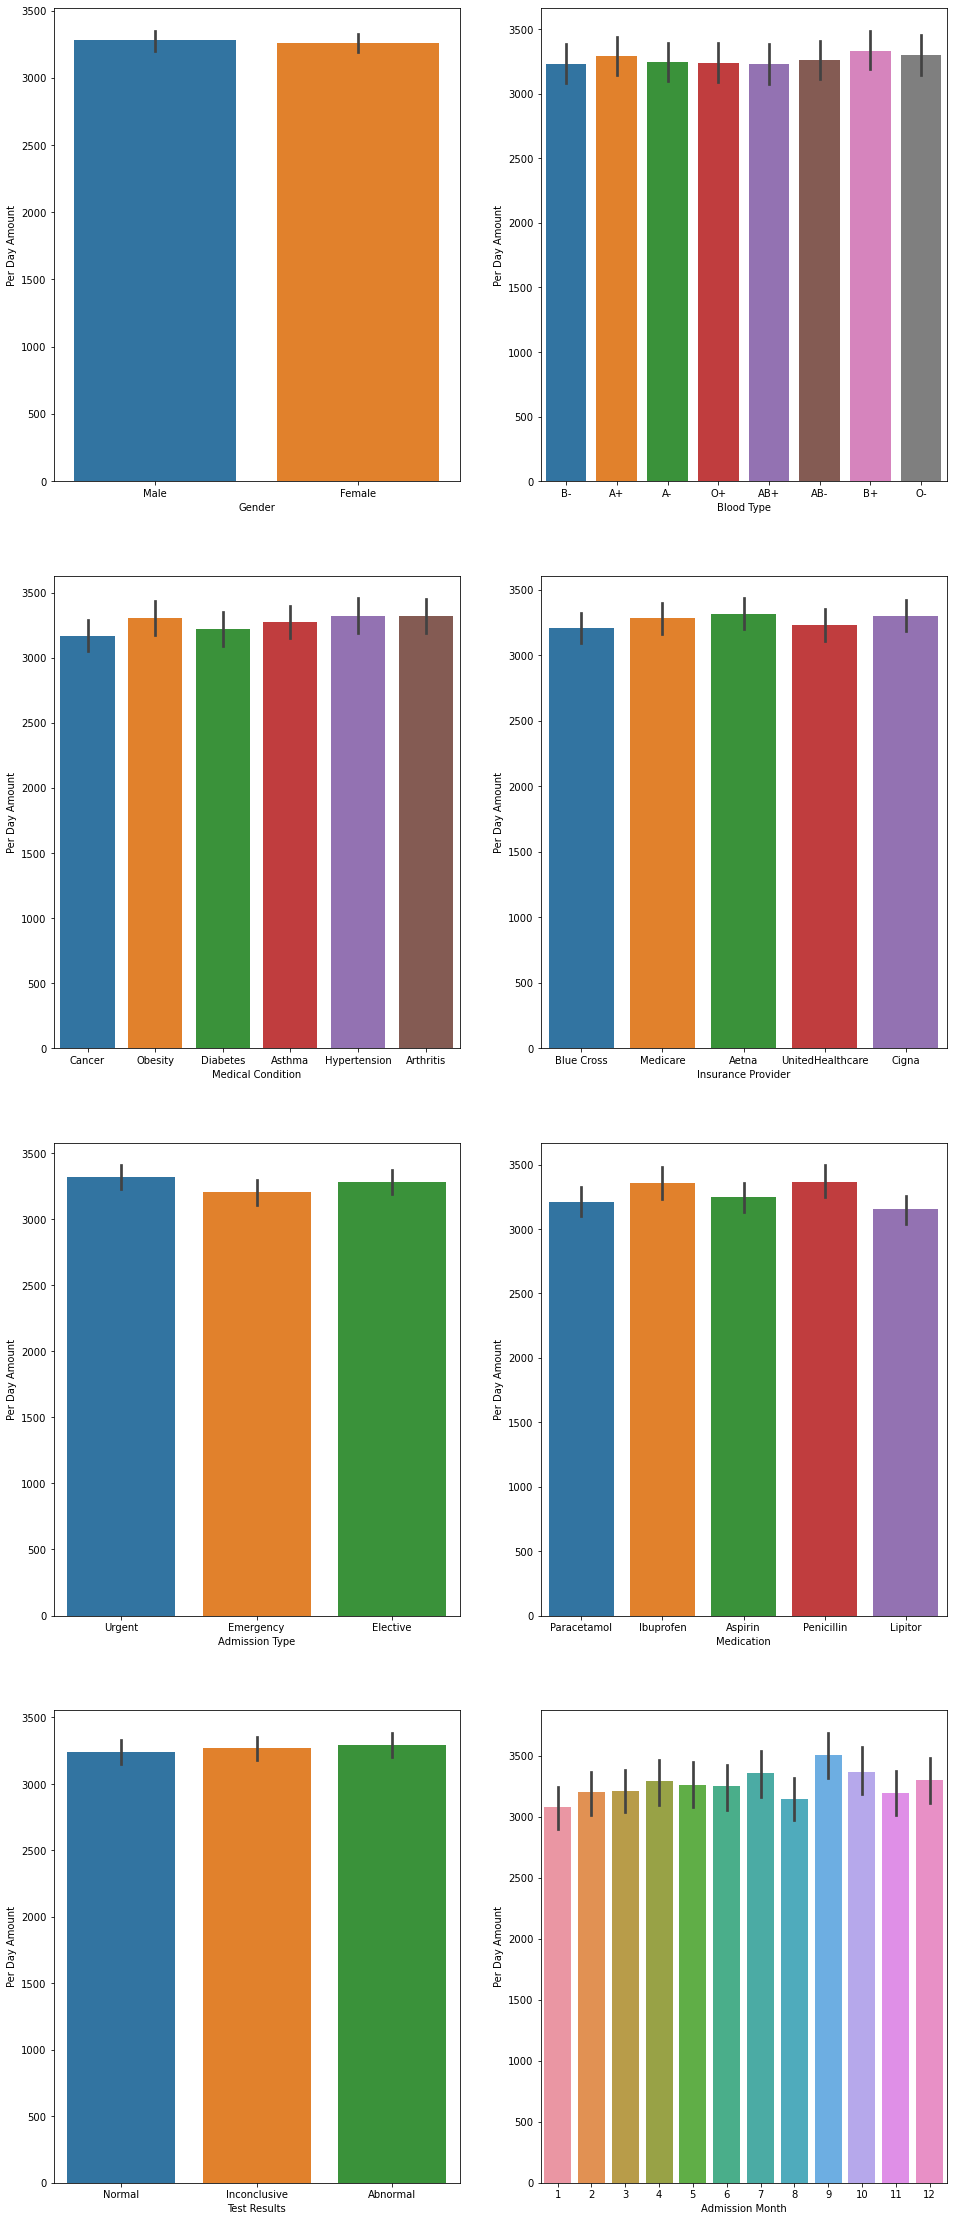

In [72]:

plt.figure(figsize = (16, 40))
plt.title("Categorical Variable VS. Per Day Amount")

plt.subplot(4,2,1)
sns.barplot(x ='Gender', y ='Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,2)
sns.barplot(x ='Blood Type', y ='Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,3)
sns.barplot(x ='Medical Condition', y ='Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,4)
sns.barplot(x ='Insurance Provider', y ='Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,5)
sns.barplot(x ='Admission Type', y ='Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,6)
sns.barplot(x ='Medication', y ='Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,7)
sns.barplot(x ='Test Results', y ='Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,8)
sns.barplot(x ='Admission Month', y ='Per Day Amount', data = df, estimator = np.std)
# plt.subplot(5,2,4)
# sns.barplot(x ='Doctor', y ='Per Day Amount', data = df, estimator = np.std)

# plt.subplot(5,2,5)
# sns.barplot(x ='Hospital', y ='Per Day Amount', data = df, estimator = np.std)

<AxesSubplot:xlabel='Admission Month', ylabel='Billing Amount'>

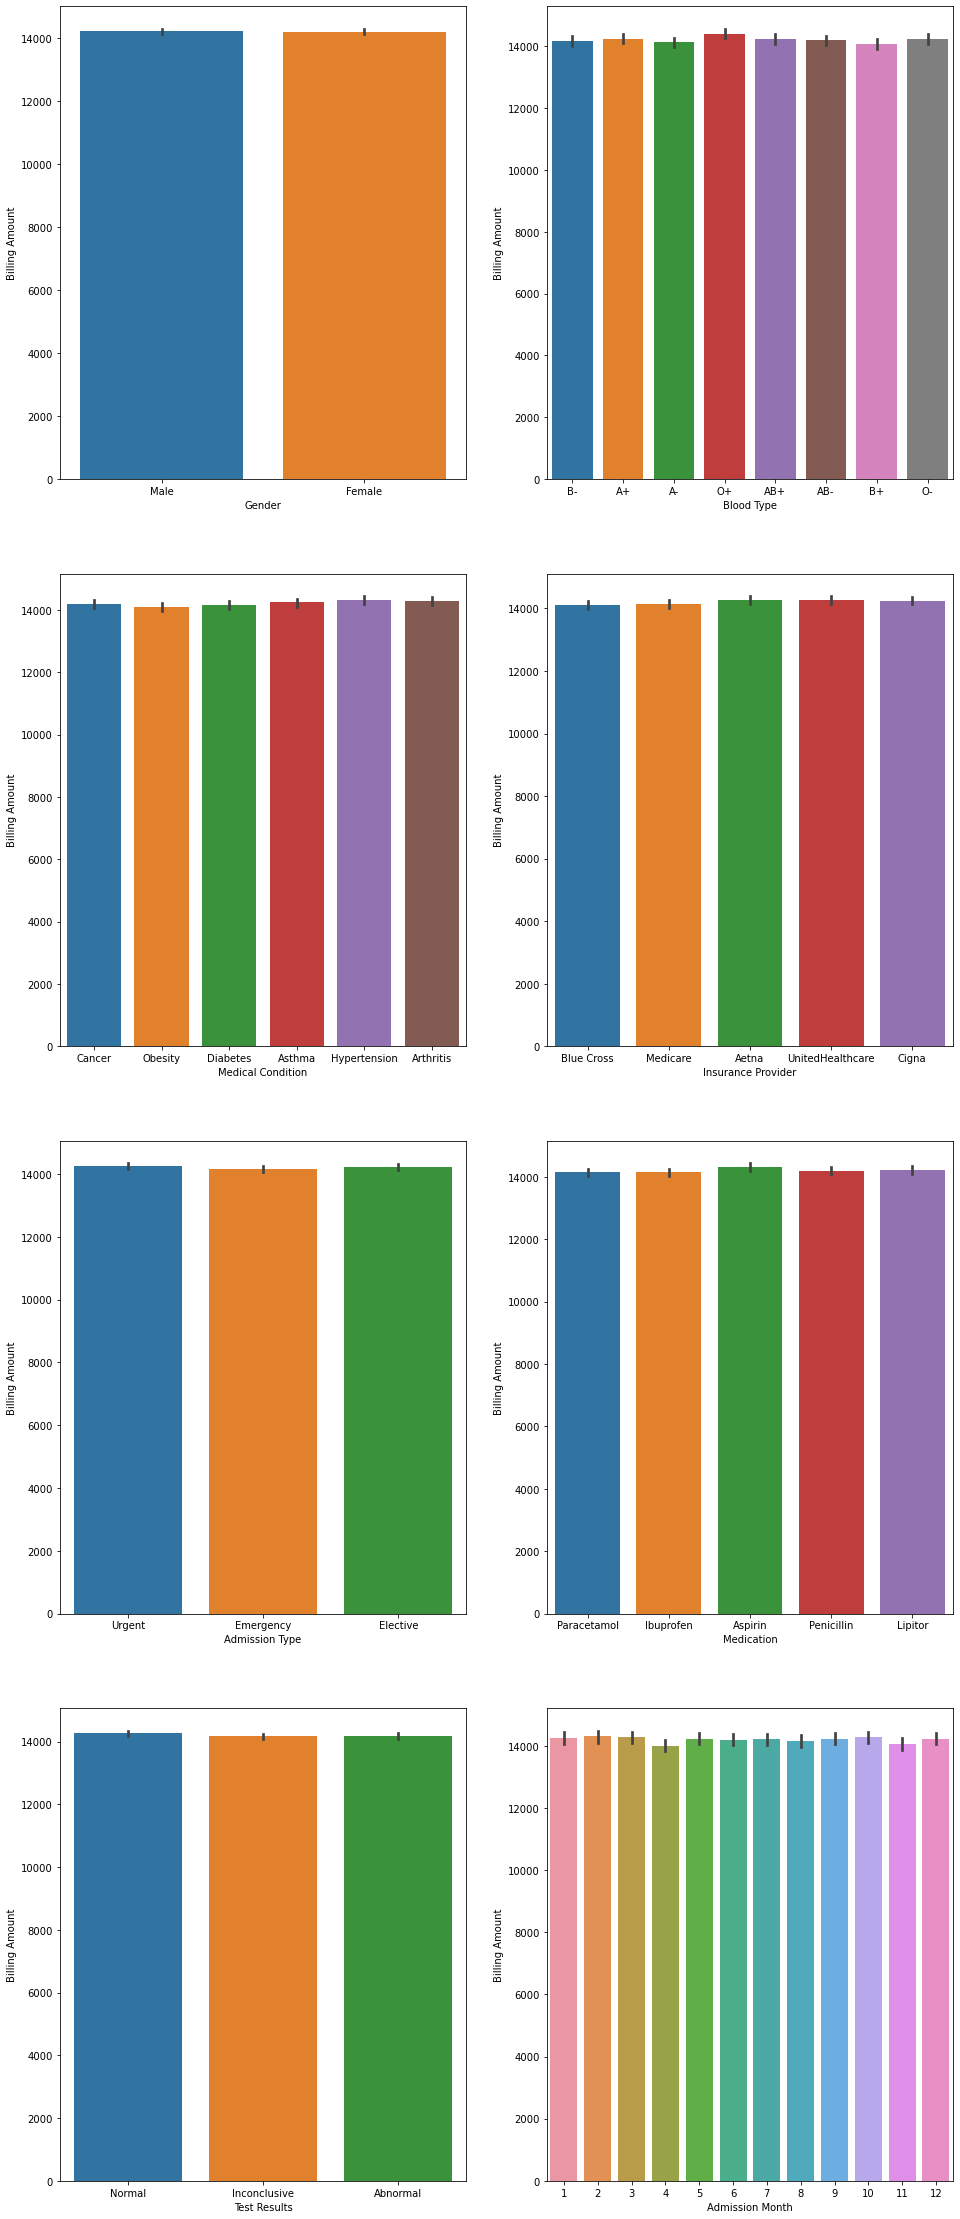

In [73]:
plt.figure(figsize = (16, 40))
plt.title("Categorical Variable VS. Billing Amount ")


plt.subplot(4,2,1)
sns.barplot(x ='Gender', y ='Billing Amount', data = df, estimator = np.std)

plt.subplot(4,2,2)
sns.barplot(x ='Blood Type', y ='Billing Amount', data = df, estimator = np.std)

plt.subplot(4,2,3)
sns.barplot(x ='Medical Condition', y ='Billing Amount', data = df, estimator = np.std)

plt.subplot(4,2,4)
sns.barplot(x ='Insurance Provider', y ='Billing Amount', data = df, estimator = np.std)

plt.subplot(4,2,5)
sns.barplot(x ='Admission Type', y ='Billing Amount', data = df, estimator = np.std)

plt.subplot(4,2,6)
sns.barplot(x ='Medication', y ='Billing Amount', data = df, estimator = np.std)

plt.subplot(4,2,7)
sns.barplot(x ='Test Results', y ='Billing Amount', data = df, estimator = np.std)

plt.subplot(4,2,8)
sns.barplot(x ='Admission Month', y ='Billing Amount', data = df, estimator = np.std)



<AxesSubplot:xlabel='Admission Month', ylabel='Log Per Day Amount'>

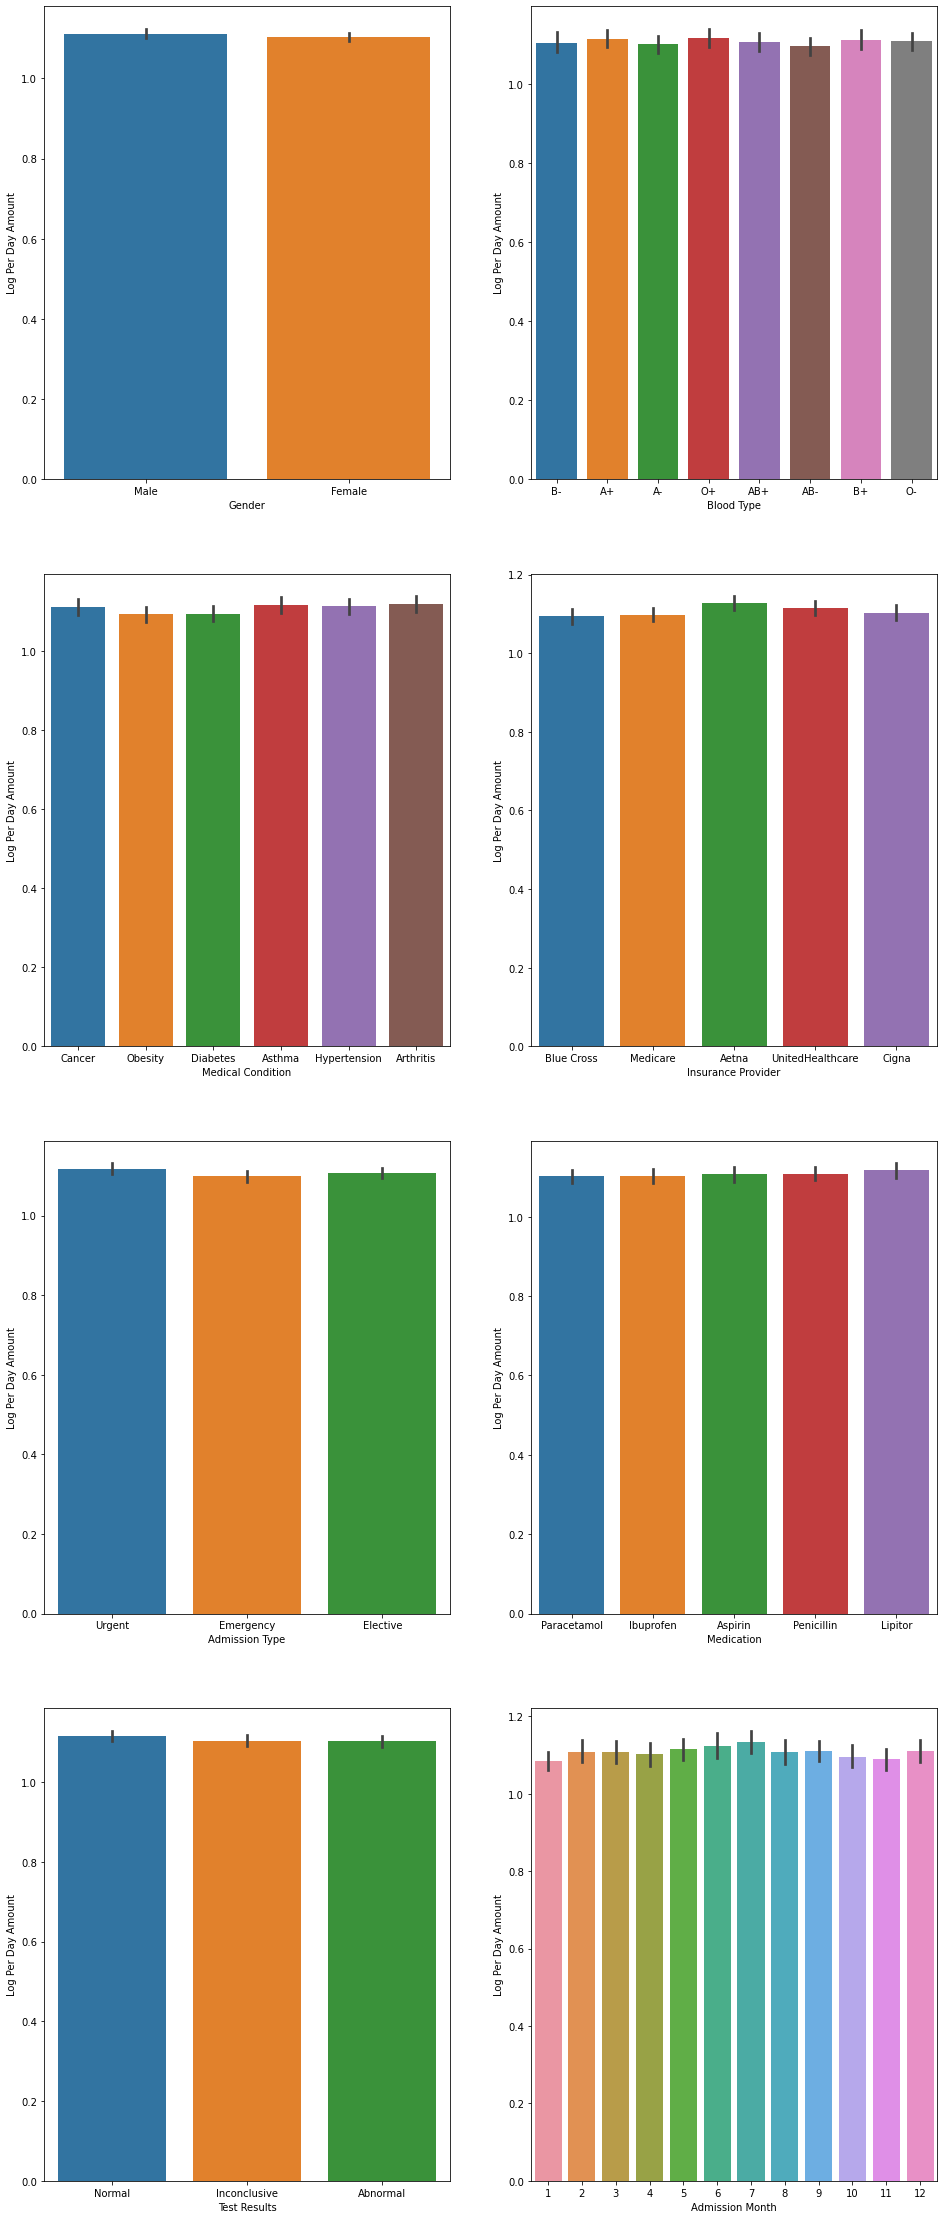

In [74]:
plt.figure(figsize = (16, 40))
plt.title("Categorical Variable VS. Log Per Day Amount ")


plt.subplot(4,2,1)
sns.barplot(x ='Gender', y ='Log Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,2)
sns.barplot(x ='Blood Type', y ='Log Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,3)
sns.barplot(x ='Medical Condition', y ='Log Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,4)
sns.barplot(x ='Insurance Provider', y ='Log Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,5)
sns.barplot(x ='Admission Type', y ='Log Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,6)
sns.barplot(x ='Medication', y ='Log Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,7)
sns.barplot(x ='Test Results', y ='Log Per Day Amount', data = df, estimator = np.std)

plt.subplot(4,2,8)
sns.barplot(x ='Admission Month', y ='Log Per Day Amount', data = df, estimator = np.std)

Plot Numerical Variable with Per day Amount 

<AxesSubplot:xlabel='Age', ylabel='Log Per Day Amount'>

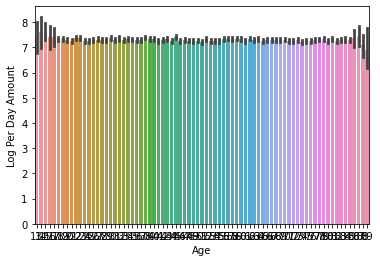

In [75]:
sns.barplot(data=df, x="Age", y="Log Per Day Amount")

<AxesSubplot:xlabel='Inpatient Days', ylabel='Log Per Day Amount'>

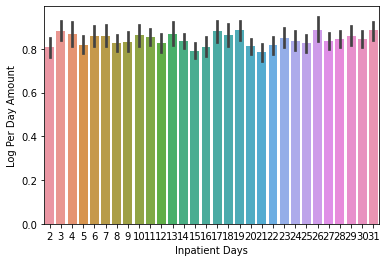

In [76]:
sns.barplot(x ='Inpatient Days', y ='Log Per Day Amount', data = df, estimator = np.std)


Check Correlation between categorical Variables 
https://medium.com/@ritesh.110587/correlation-between-categorical-variables-63f6bd9bf2f7
Chi-Square Test 

In [77]:
## Importing required libraries
import os as os
import pandas as pd
from itertools import product
import numpy as np
import scipy.stats as ss

In [83]:
#Get all Categorical variables 
df_chi = df.drop(columns=["Doctor","Hospital"])
df_cat = pd.DataFrame(data = df_chi.dtypes, columns = ['a']).reset_index()
cat_var = list(df_cat['index'].loc[df_cat['a'] == 'object'])

In [84]:
cat_var

['Gender',
 'Blood Type',
 'Medical Condition',
 'Insurance Provider',
 'Admission Type',
 'Medication',
 'Test Results']

In [85]:
df_cat = df[cat_var]
df_cat

,Gender,Blood Type,Medical Condition,Insurance Provider,Admission Type,Medication,Test Results
0,Male,B-,Cancer,Blue Cross,Urgent,Paracetamol,Normal
1,Male,A+,Obesity,Medicare,Emergency,Ibuprofen,Inconclusive
2,Female,A-,Obesity,Aetna,Emergency,Aspirin,Normal
3,Female,O+,Diabetes,Medicare,Elective,Ibuprofen,Abnormal
4,Female,AB+,Cancer,Aetna,Urgent,Penicillin,Abnormal
...,...,...,...,...,...,...,...
55495,Female,O+,Asthma,Blue Cross,Elective,Penicillin,Abnormal
55496,Female,AB-,Obesity,Cigna,Elective,Aspirin,Normal
55497,Female,B+,Hypertension,UnitedHealthcare,Urgent,Ibuprofen,Abnormal
55498,Male,O-,Arthritis,Medicare,Elective,Ibuprofen,Abnormal


In [86]:
cat_var1 = ('Gender','Blood Type','Medical Condition','Insurance Provider','Admission Type',
 'Medication','Test Results')

cat_var2 = ('Gender','Blood Type','Medical Condition','Insurance Provider','Admission Type',
 'Medication','Test Results')
## Let us jump to Chi-Square test
## Creating all possible combinations between the above two variables list

cat_var_prod = list(product(cat_var1,cat_var2, repeat = 1))

In [87]:
cat_var_prod

[('Gender', 'Gender'),
 ('Gender', 'Blood Type'),
 ('Gender', 'Medical Condition'),
 ('Gender', 'Insurance Provider'),
 ('Gender', 'Admission Type'),
 ('Gender', 'Medication'),
 ('Gender', 'Test Results'),
 ('Blood Type', 'Gender'),
 ('Blood Type', 'Blood Type'),
 ('Blood Type', 'Medical Condition'),
 ('Blood Type', 'Insurance Provider'),
 ('Blood Type', 'Admission Type'),
 ('Blood Type', 'Medication'),
 ('Blood Type', 'Test Results'),
 ('Medical Condition', 'Gender'),
 ('Medical Condition', 'Blood Type'),
 ('Medical Condition', 'Medical Condition'),
 ('Medical Condition', 'Insurance Provider'),
 ('Medical Condition', 'Admission Type'),
 ('Medical Condition', 'Medication'),
 ('Medical Condition', 'Test Results'),
 ('Insurance Provider', 'Gender'),
 ('Insurance Provider', 'Blood Type'),
 ('Insurance Provider', 'Medical Condition'),
 ('Insurance Provider', 'Insurance Provider'),
 ('Insurance Provider', 'Admission Type'),
 ('Insurance Provider', 'Medication'),
 ('Insurance Provider', 'Tes

In [88]:
## Creating an empty variable and picking only the p value from the output of Chi-Square test
result = []
for i in cat_var_prod:
    if i[0] != i[1]:
        result.append((i[0],i[1],list(ss.chi2_contingency(pd.crosstab(df_cat[i[0]], df_cat[i[1]])))[1]))

result


[('Gender', 'Blood Type', 0.050183339982405664),
 ('Gender', 'Medical Condition', 0.956544546171692),
 ('Gender', 'Insurance Provider', 0.5268026232731005),
 ('Gender', 'Admission Type', 0.0074067158746289104),
 ('Gender', 'Medication', 0.19829219701577566),
 ('Gender', 'Test Results', 0.33543877922666065),
 ('Blood Type', 'Gender', 0.050183339982405574),
 ('Blood Type', 'Medical Condition', 0.4768576696256961),
 ('Blood Type', 'Insurance Provider', 0.22878918078550556),
 ('Blood Type', 'Admission Type', 0.3949850780527361),
 ('Blood Type', 'Medication', 0.4308432437758112),
 ('Blood Type', 'Test Results', 0.8892322033448401),
 ('Medical Condition', 'Gender', 0.956544546171692),
 ('Medical Condition', 'Blood Type', 0.4768576696256961),
 ('Medical Condition', 'Insurance Provider', 0.7374667931661414),
 ('Medical Condition', 'Admission Type', 0.05684174826535973),
 ('Medical Condition', 'Medication', 0.4003463798737443),
 ('Medical Condition', 'Test Results', 0.20888060455523685),
 ('Ins

In [89]:
chi_test_output = pd.DataFrame(result,columns = ["var1", "var2", "coeff"])
                                                  
## Using pivot function to convert the above DataFrame into a crosstab
chi_test_output.pivot(index="var1", columns="var2", values="coeff")

var2,Admission Type,Blood Type,Gender,Insurance Provider,Medical Condition,Medication,Test Results
var1,,,,,,,
Admission Type,NaN,0.394985,0.007407,0.019766,0.056842,0.683589,0.800076
Blood Type,0.394985,NaN,0.050183,0.228789,0.476858,0.430843,0.889232
Gender,0.007407,0.050183,NaN,0.526803,0.956545,0.198292,0.335439
Insurance Provider,0.019766,0.228789,0.526803,NaN,0.737467,0.867785,0.339384
Medical Condition,0.056842,0.476858,0.956545,0.737467,NaN,0.400346,0.208881
Medication,0.683589,0.430843,0.198292,0.867785,0.400346,NaN,0.870234
Test Results,0.800076,0.889232,0.335439,0.339384,0.208881,0.870234,NaN


Admission Type highly correlated with Medication and Test Results 
Blood Type Highly Correlated with Test Result 
Gender Highly Correlated with Gender 
Insurance Provider correlated with Medical condition adn Medication 
Medication Highly cocrelated with Test Results 

In [36]:
Y = df["Per Day Amount"]

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics

label_encoder = LabelEncoder()

for col in cat_var:
    df_cat[col] = label_encoder.fit_transform(df_cat[col])


# Splitting the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(df_cat, Y, test_size=0.2, random_state=42)

/var/folders/bl/2vpb_l0x3055wtj059j4xsjr0000gn/T/ipykernel_862/323401322.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cat[col] = label_encoder.fit_transform(df_cat[col])


In [39]:
#Logistic Regression
LOG = LogisticRegression(max_iter=200,solver='liblinear').fit(xtrain, ytrain) 

#training error
log_ypred_train = LOG.predict(xtrain)
log_train_acct=metrics.accuracy_score(ytrain, log_ypred_train)
print("Training accuracy for Logistic Regression: ",log_train_acct)

#testing error
log_ypred_test = LOG.predict(xtest)
log_test_acct=metrics.accuracy_score(ytest, log_ypred_test)
print("Testing accuracy for Logistic Regression: ",log_test_acct)

ValueError: Unknown label type: 'continuous'